In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import statsmodels.api as sm
import matplotlib.dates as mdates


pub_gray = '#cecece'
pub_purple = '#a559aa'
pub_teal = '#59a89c'
pub_gold = '#f0c571'
pub_red = '#e02b35'
pub_blue = '#082a54'


plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Helvetica',
    'mathtext.fontset': 'stix',
    
    'figure.figsize': [10, 6],
    'figure.dpi': 300,
    
    'axes.linewidth': 1.2,
    'axes.labelsize': 12,
    'axes.grid': True,
    'axes.titlesize': 12,
    
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'lines.markeredgewidth': .2,
    
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    
    'legend.fontsize': 12,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'legend.framealpha': 0.95,
    
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})

In [2]:
df = pd.read_csv('../../data/processed/training_data.csv')

start_time = '2025-06-21 06:00:00+00:00'  
end_time = '2025-06-21 20:00:00+00:00'
df_single_day = df[(df['time'] >= start_time) & (df['time'] <= end_time)]

df = df_single_day.copy()


T_ref = df['temperature'].iloc[0]
H_ref = df['humidity'].iloc[0]
P_ref = df['pressure'].iloc[0] * 100  # hPa → Pa
n_ref = df['n_1762'].iloc[0]

wavelength = 1762e-9  # 1762 nm
L = 4.2
conversion_factor = (2 * np.pi / wavelength) * L

df['phase_measured'] = (df['n_1762'] - n_ref) * conversion_factor
df['time'] = pd.to_datetime(df['time'])

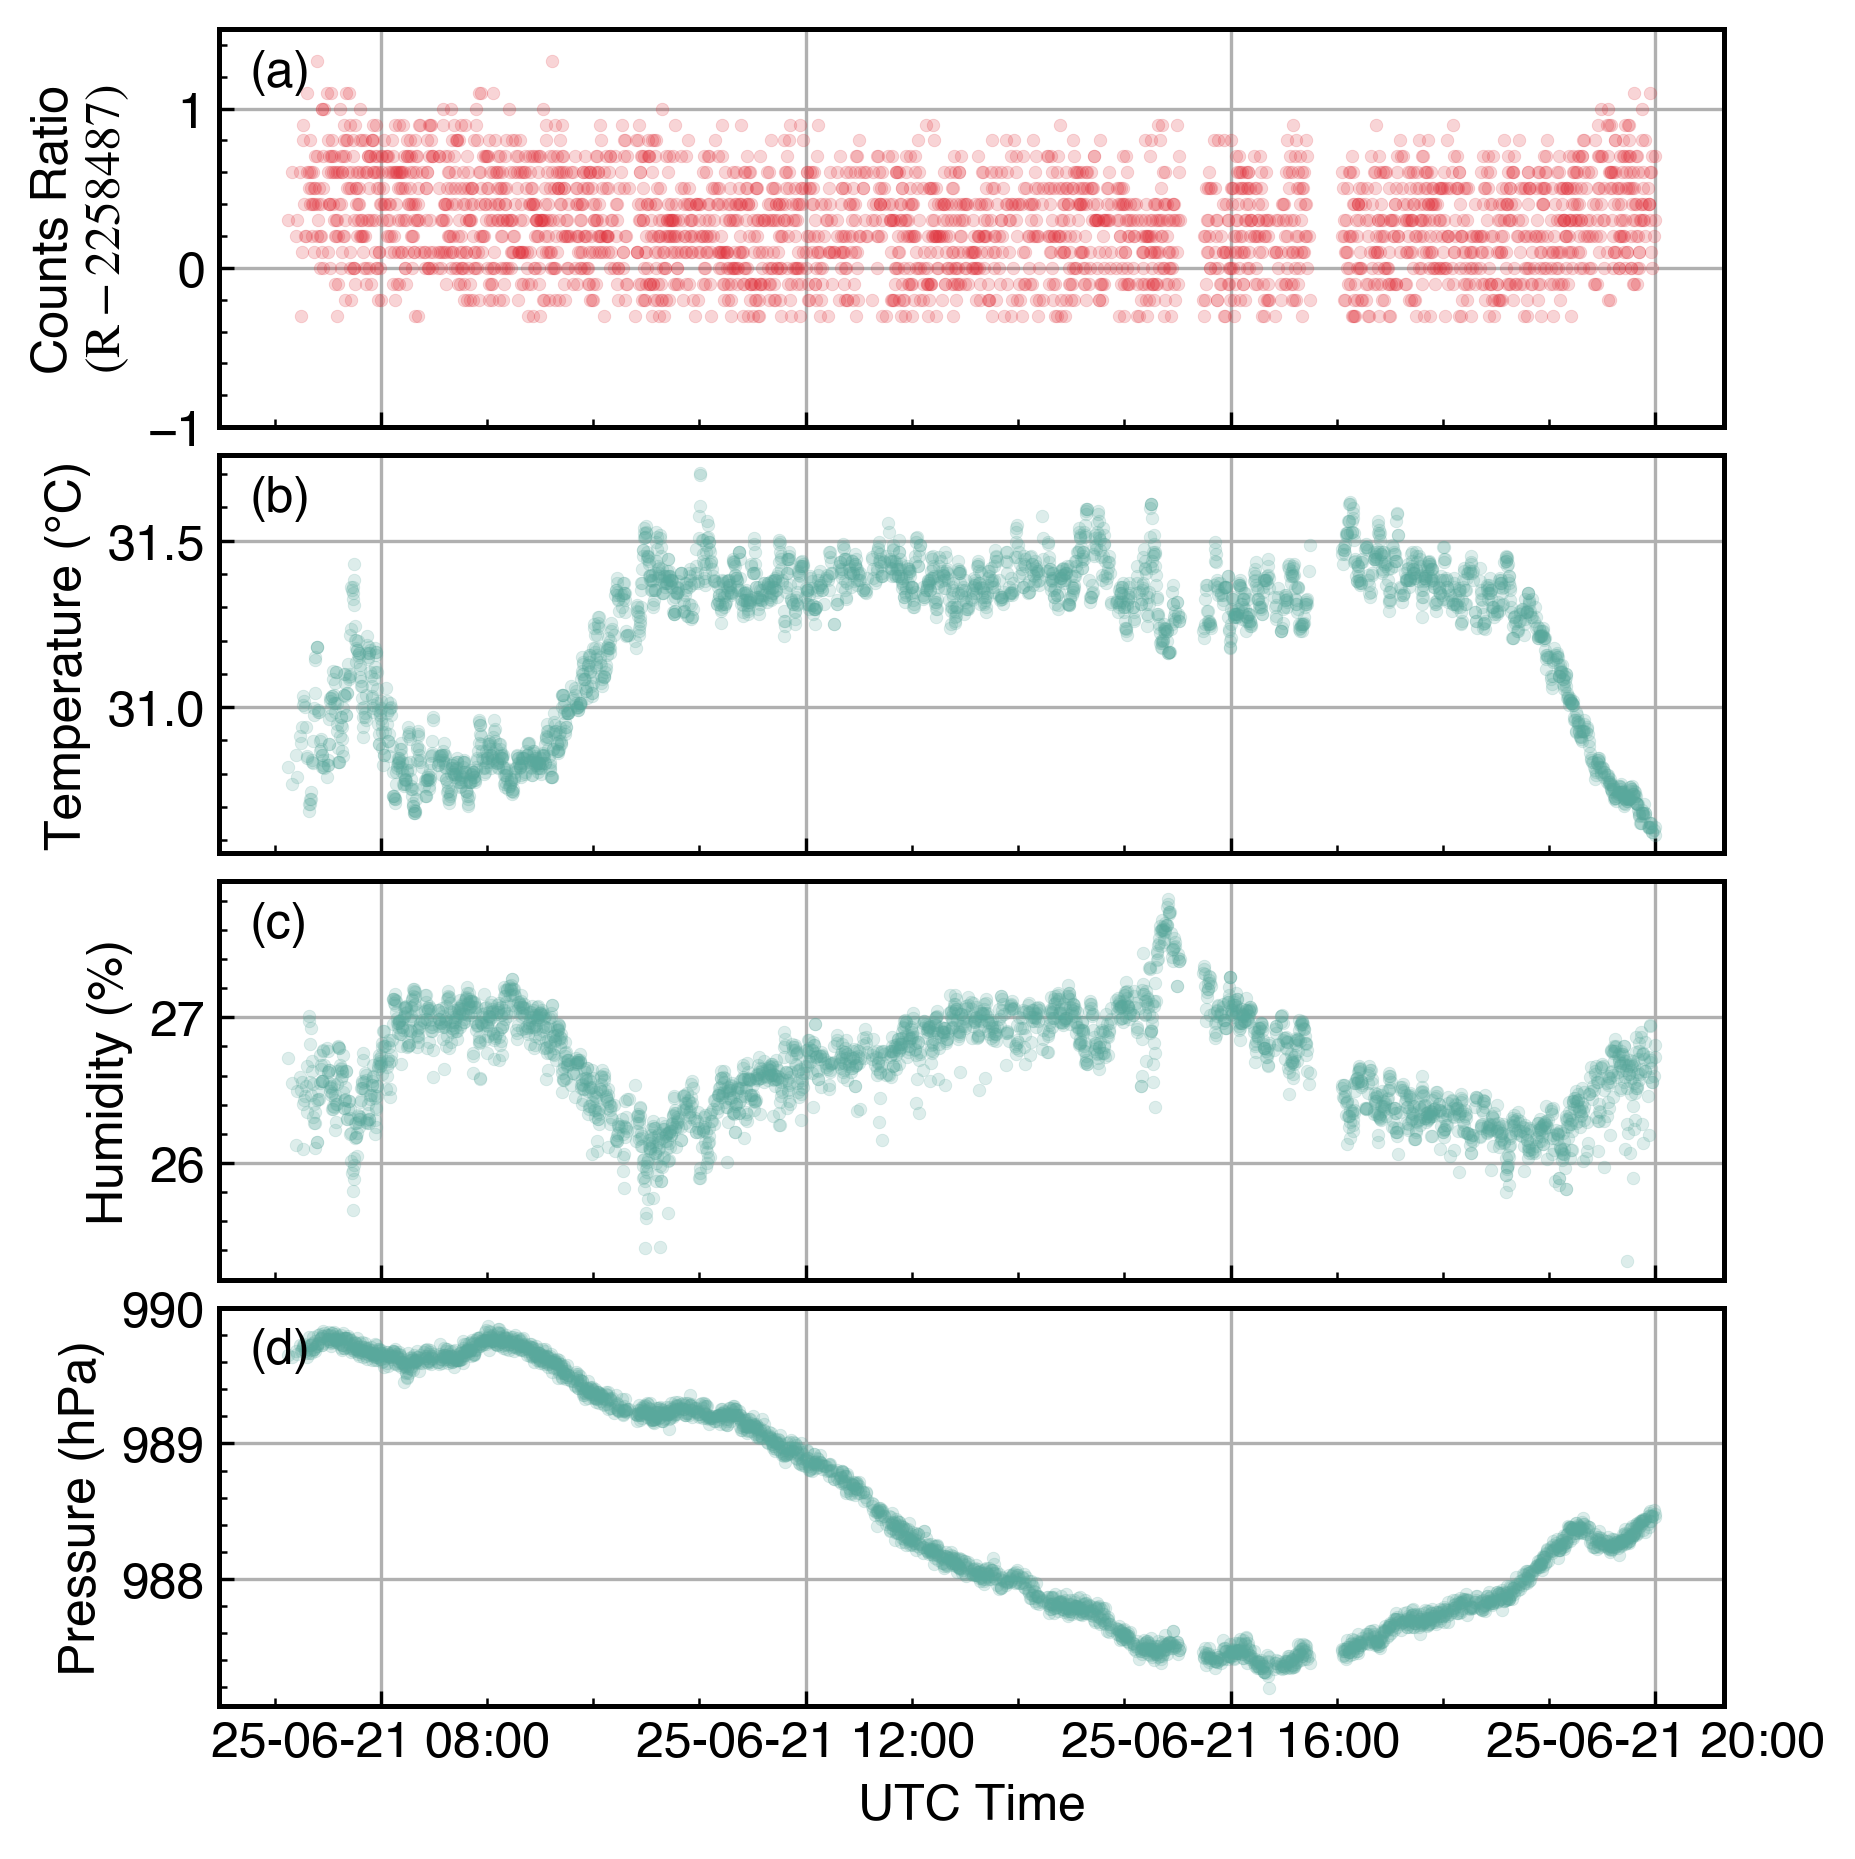

In [6]:
alpha = 0.2
plotstyle = '.'

fig, ax = plt.subplots(4, figsize=(6, 6), sharex=True)

ax[0].plot(df['time'], (df['counts_ratio']-2.258487)*1e6, plotstyle, alpha=alpha, color=pub_red)
ax[0].set_ylim(-1, 1.5)
ax[0].set_ylabel('Counts Ratio\n' + r'$(\mathrm{R}-2258487)$')
ax[0].text(0.02, 0.95, '(a)', transform=ax[0].transAxes, va='top', ha='left', fontweight='bold')

ax[1].plot(df['time'], df['temperature'], plotstyle, alpha=alpha, color=pub_teal)
ax[1].set_ylabel('Temperature (°C)')
ax[1].text(0.02, 0.95, '(b)', transform=ax[1].transAxes, va='top', ha='left', fontweight='bold')

ax[2].plot(df['time'], df['humidity'], plotstyle, alpha=alpha, color=pub_teal)
ax[2].set_ylabel('Humidity (%)')
ax[2].text(0.02, 0.95, '(c)', transform=ax[2].transAxes, va='top', ha='left', fontweight='bold')

ax[3].plot(df['time'], df['pressure'], plotstyle, alpha=alpha, color=pub_teal)
ax[3].set_ylabel('Pressure (hPa)')
ax[3].text(0.02, 0.95, '(d)', transform=ax[3].transAxes, va='top', ha='left', fontweight='bold')
ax[3].set_xlabel('UTC Time')
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d %H:%M'))
ax[3].xaxis.set_major_locator(mdates.HourLocator(interval=4))

plt.tight_layout(pad=0, h_pad=0, w_pad=0)
plt.savefig('../../data/derived/figures/data_preview.pdf', dpi=300, bbox_inches='tight')
plt.show()
